In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mediapipe as mp

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import CLIP_METADATA_PATH
from src.video_utils import (
    load_clip_metadata,
    validate_video_paths,
    get_video_frame_count,
    load_sampled_frames,
)
from src.pose_extraction import (
    initialize_pose_estimator,
    extract_pose_sequence,
    draw_pose_on_frame,
    count_missing_pose_frames,
)
from src.preprocessing import (
    clean_landmark_sequence,
    normalize_landmark_sequence,
    pad_or_truncate_sequence,
    flatten_landmark_sequence,
    preprocess_landmark_sequence,
)

In [2]:
print("MediaPipe version:", mp.__version__)

MediaPipe version: 0.10.21


In [3]:
df = load_clip_metadata(CLIP_METADATA_PATH)
df_checked = validate_video_paths(df)

print("All files exist:", df_checked["file_exists"].all())
df_checked.head()

All files exist: True


,clip_id,video_path,label,absolute_path,file_exists
0,bad_jump_01,data/raw/bad/bad_jump_01.MOV,bad_jump,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,True
1,bad_jump_02,data/raw/bad/bad_jump_02.MOV,bad_jump,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,True
2,bad_jump_03,data/raw/bad/bad_jump_03.MOV,bad_jump,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,True
3,bad_jump_04,data/raw/bad/bad_jump_04.MOV,bad_jump,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,True
4,bad_jump_05,data/raw/bad/bad_jump_05.MOV,bad_jump,/Users/arjunrammohandas/Desktop/JumpSafe_Conti...,True


In [4]:
# Use the first available clip as a pose-debug example
sample_row = df_checked.iloc[0]

video_path = sample_row["absolute_path"]
label = sample_row["label"]
clip_id = sample_row["clip_id"]

print("Clip ID:", clip_id)
print("Label:", label)
print("Video path:", video_path)

Clip ID: bad_jump_01
Label: bad_jump
Video path: /Users/arjunrammohandas/Desktop/JumpSafe_Continuation/data/raw/bad/bad_jump_01.MOV


In [5]:
frame_count = get_video_frame_count(video_path)
print("Frame count:", frame_count)

Frame count: 169


In [ ]:
#frame shape
frames, frame_indices = load_sampled_frames(video_path, num_samples=6)

print("Loaded frames:", len(frames))
print("Frame indices:", frame_indices)
print("Frame shape:", frames[0].shape)

Loaded frames: 6
Frame indices: [  0  33  67 100 134 168]
Frame shape: (1080, 1920, 3)


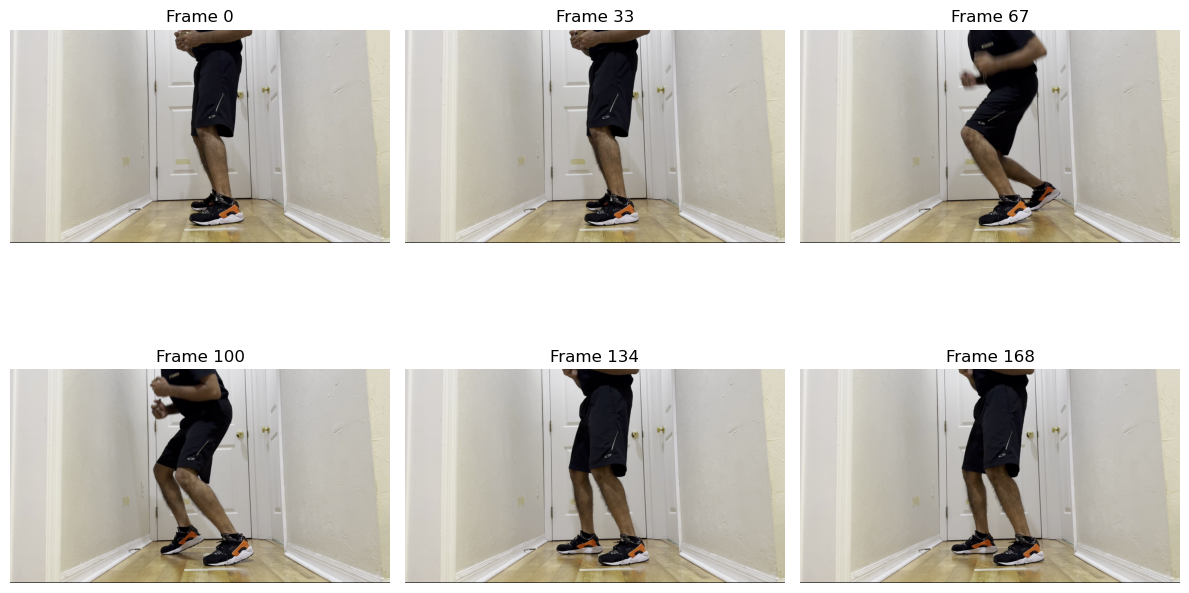

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, frame, idx in zip(axes, frames, frame_indices):
    ax.imshow(frame)
    ax.set_title(f"Frame {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Pose estimator
pose_estimator = initialize_pose_estimator()

landmark_sequence, pose_results = extract_pose_sequence(frames, pose_estimator)

print("Landmark sequence shape:", landmark_sequence.shape)
print("Missing-pose frames:", count_missing_pose_frames(landmark_sequence))

Landmark sequence shape: (6, 33, 4)
Missing-pose frames: 0


I0000 00:00:1775846259.619845 38865954 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775846259.694821 38866100 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775846259.706387 38866103 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775846259.722005 38866106 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


In [9]:
overlay_frames = [
    draw_pose_on_frame(frame, result)
    for frame, result in zip(frames, pose_results)
]

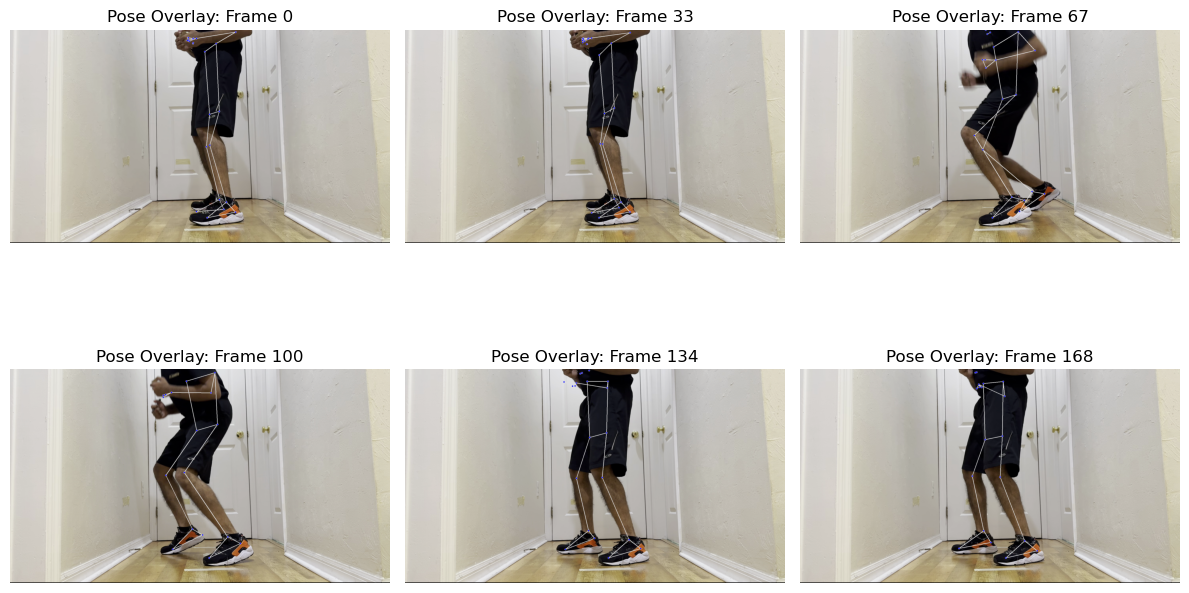

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, frame, idx in zip(axes, overlay_frames, frame_indices):
    ax.imshow(frame)
    ax.set_title(f"Pose Overlay: Frame {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
cleaned_sequence = clean_landmark_sequence(landmark_sequence)
normalized_sequence = normalize_landmark_sequence(cleaned_sequence)
fixed_sequence = pad_or_truncate_sequence(normalized_sequence, target_length=30)
flattened_sequence = flatten_landmark_sequence(fixed_sequence)

print("Raw shape:", landmark_sequence.shape)
print("Cleaned shape:", cleaned_sequence.shape)
print("Normalized shape:", normalized_sequence.shape)
print("Fixed-length shape:", fixed_sequence.shape)
print("Flattened shape:", flattened_sequence.shape)

Raw shape: (6, 33, 4)
Cleaned shape: (6, 33, 4)
Normalized shape: (6, 33, 4)
Fixed-length shape: (30, 33, 4)
Flattened shape: (30, 132)


In [12]:
processed_sequence = preprocess_landmark_sequence(landmark_sequence, target_length=30)

print("Processed sequence shape:", processed_sequence.shape)
print("Contains NaNs:", np.isnan(processed_sequence).any())
print("Contains infs:", np.isinf(processed_sequence).any())

Processed sequence shape: (30, 132)
Contains NaNs: False
Contains infs: False


In [13]:
pose_estimator.close()